In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

In [9]:
#load dataset
df = pd.read_csv("college_student_placement_dataset.csv")
df.head()

,College_ID,IQ level,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [10]:
# preprocessing
#check missing values
df.isnull().sum()
# verify
df.isnull().sum()
#drop unnecessary column
df = df.drop("College_ID", axis=1)
# rename column
df.rename(columns={'IQ level': 'IQ_level'}, inplace=True)

In [11]:
# label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Internship_Experience'] = le.fit_transform(df['Internship_Experience'])
df['Placement'] = le.fit_transform(df['Placement'])
df.head(10)

,IQ_level,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,0
1,97,5.52,5.37,8,0,7,8,0,0
2,109,5.36,5.83,9,0,3,1,1,0
3,122,5.47,5.75,6,1,1,6,1,0
4,96,7.91,7.69,7,0,8,10,2,0
5,96,5.26,5.32,7,0,5,8,0,0
6,123,6.68,6.58,5,0,7,8,2,1
7,111,8.77,8.76,7,0,3,1,2,1
8,92,6.47,6.33,9,0,7,8,5,0
9,108,8.82,8.60,4,0,5,9,1,0


In [12]:
# feature engineering
df['Total_Score'] = df['CGPA'] + df['Academic_Performance'] + df['Prev_Sem_Result']
df['Skills_Score'] = df['Communication_Skills'] + df['Extra_Curricular_Score'] + df['Projects_Completed']
df['Experience_Score'] = df['Internship_Experience'] + df['Projects_Completed']

In [13]:
# Feature selection
features = ['IQ_level', 'Total_Score', 'Skills_Score', 'Experience_Score']
X = df[features]
y = df['Placement']

In [14]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.ensemble import RandomForestClassifier

# random forest model

rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# prediction
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluation
print("Random Forest Results:")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Random Forest Results:
Train Accuracy: 0.9763729246487867
Test Accuracy: 0.8698979591836735


In [16]:
from sklearn.metrics import classification_report

# y_test = actual labels
# y_pred = predictions from your model
y_pred = rf_model.predict(X_test)  # Random Forest predictions

print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       323
           1       0.62      0.70      0.65        69

    accuracy                           0.87       392
   macro avg       0.77      0.80      0.79       392
weighted avg       0.88      0.87      0.87       392



In [17]:
import joblib

joblib.dump(rf_model, "RandomForestFinal.pkl")
print("✅ RandomForestFinal.pkl created successfully!")

✅ RandomForestFinal.pkl created successfully!


In [18]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[293  30]
 [ 21  48]]


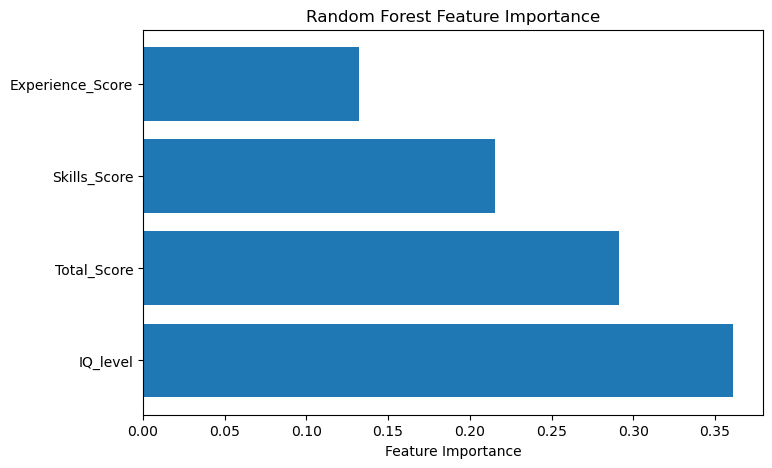

In [19]:
# Feature Importance Plot
import matplotlib.pyplot as plt
importances = rf_model.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

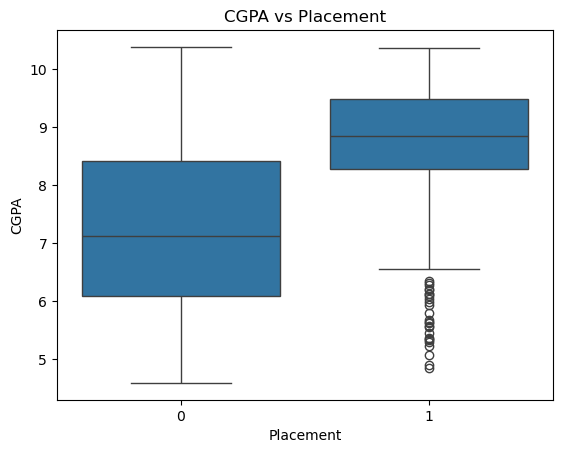

In [20]:
#CGPA vs Placement
#Box plot
import seaborn as sns
sns.boxplot(x='Placement', y='CGPA', data=df)
plt.title("CGPA vs Placement")
plt.show()

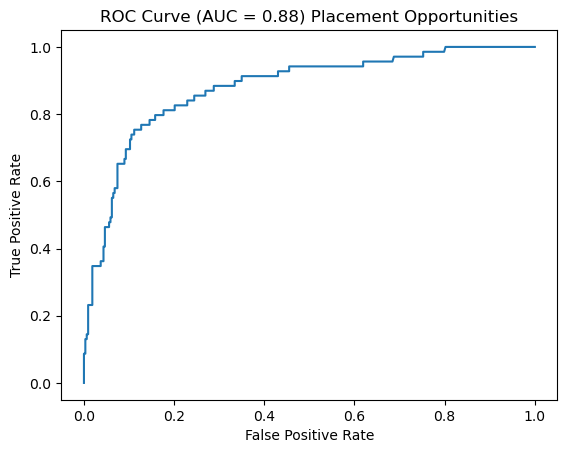

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Get probability scores
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.2f) Placement Opportunities" % roc_auc)
plt.show()

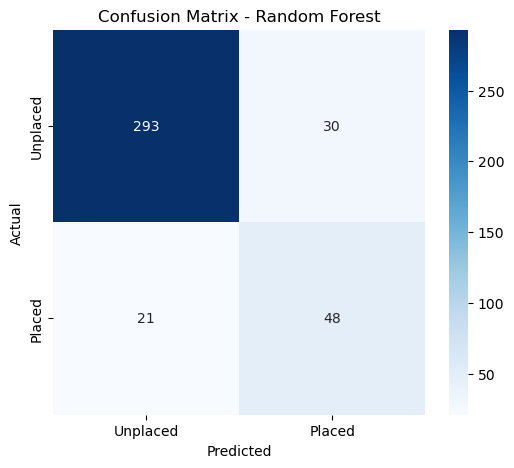

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix for test data
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Unplaced','Placed'], yticklabels=['Unplaced','Placed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()